# 04 - Model Building
Train baseline ML models and evaluate performance.

✅ Dataset loaded → 102,904 rows × 25 columns
🎯 Target 'is_delayed_high' created. Class distribution:
is_delayed_high
0    0.500078
1    0.499922
Name: proportion, dtype: float64
💾 Encoding mappings saved → C:\Users\gowda\Downloads\FDS PROJECT\Airline_Flight_Delay_Prediction\dataset\encoding_mappings.json
🔠 Encoded columns: ['airport', 'airport_name', 'carrier', 'carrier_name']
🧩 Train: (82323, 21), Test: (20581, 21)
📏 Numeric features scaled successfully.

📊 Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     10292
           1       1.00      0.96      0.98     10289

    accuracy                           0.98     20581
   macro avg       0.98      0.98      0.98     20581
weighted avg       0.98      0.98      0.98     20581

ROC-AUC: 0.9993


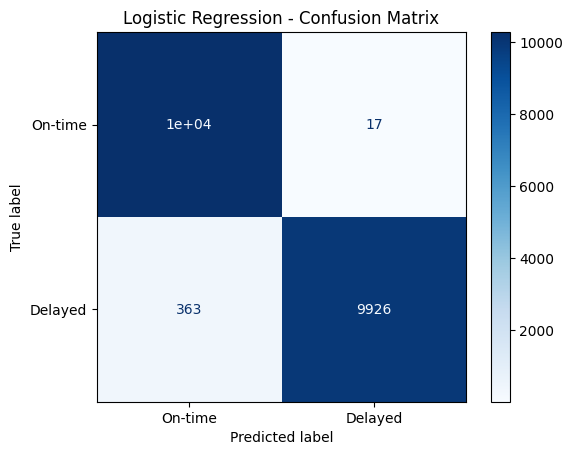


📊 Random Forest Results:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     10292
           1       0.97      0.98      0.97     10289

    accuracy                           0.97     20581
   macro avg       0.97      0.97      0.97     20581
weighted avg       0.97      0.97      0.97     20581

ROC-AUC: 0.9971


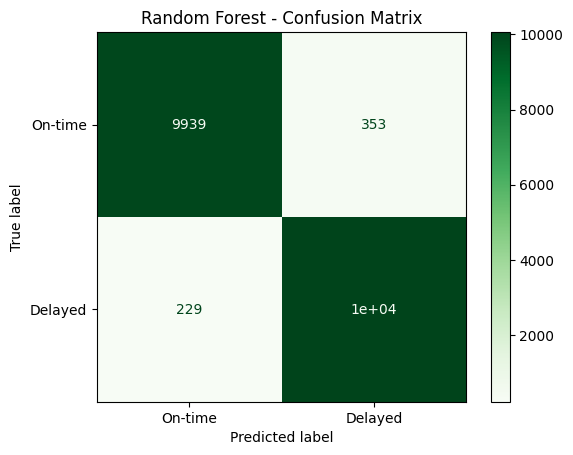

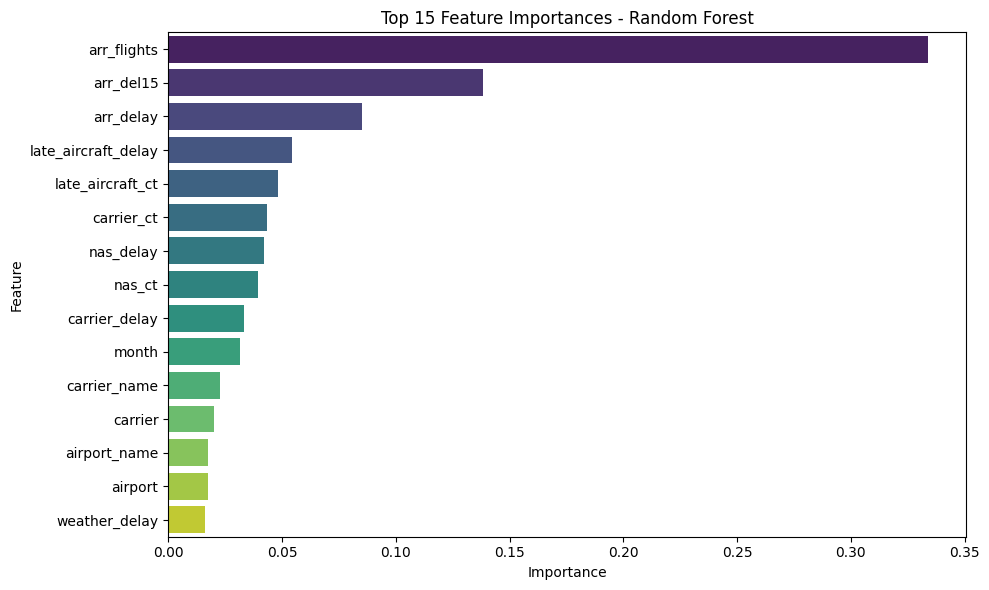

💾 Model saved → C:\Users\gowda\Downloads\FDS PROJECT\Airline_Flight_Delay_Prediction\models\best_model.pkl
📊 Power BI-ready predictions saved → C:\Users\gowda\Downloads\FDS PROJECT\Airline_Flight_Delay_Prediction\dataset\model_predictions.csv

📈 Model Summary:
                  Model   ROC-AUC  Accuracy
0  Logistic Regression  0.999262  0.981536
1        Random Forest  0.997079  0.971721


In [ ]:
# ---------------------------------------------
# File: 04_model_building_final_decoded.ipynb
# Purpose: Train ML models and export Power BI-readable results
# Author: Kushalgowda
# ---------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
warnings.filterwarnings('ignore')

# ===============================
# 1️ Load dataset
# ===============================
df = pd.read_csv(r'C:\Users\gowda\Downloads\FDS PROJECT\Airline_Flight_Delay_Prediction\dataset\flights_ready.csv')
print(f" Dataset loaded → {df.shape[0]:,} rows × {df.shape[1]} columns")

# ===============================
# 2️ Create target variable
# ===============================
if 'delay_rate' not in df.columns:
    raise ValueError("'delay_rate' column not found. Please create it during cleaning.")

median_delay = df['delay_rate'].median()
df['is_delayed_high'] = (df['delay_rate'] > median_delay).astype(int)
print(f"🎯 Target 'is_delayed_high' created. Class distribution:\n{df['is_delayed_high'].value_counts(normalize=True)}")

# ===============================
# 3️ Define features
# ===============================
features_to_drop = [
    'delay_rate', 'cancel_rate', 'divert_rate',
    'total_delay_minutes', 'is_delayed_high'
]
X = df.drop(columns=features_to_drop)
y = df['is_delayed_high']

# ===============================
# 4️Encode categorical features
# ===============================
cat_cols = X.select_dtypes(include='object').columns.tolist()
encoders = {}
decoded_columns = pd.DataFrame()  # for decoded copy later

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    decoded_columns[col + "_decoded"] = df[col]  # Keep readable version

# Save encoding mapping
mapping_path = r'C:\Users\gowda\Downloads\FDS PROJECT\Airline_Flight_Delay_Prediction\dataset\encoding_mappings.json'
encoders_json = {col: {str(k): int(v) for k, v in mapping.items()} for col, mapping in encoders.items()}
with open(mapping_path, 'w') as f:
    json.dump(encoders_json, f, indent=4)
print(f" Encoding mappings saved → {mapping_path}")
print(f" Encoded columns: {cat_cols}")

# ===============================
# 5️Train-test split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f" Train: {X_train.shape}, Test: {X_test.shape}")

# Unscaled readable copy for decoded output
X_test_unscaled = X_test.copy()

# ===============================
# 6️ Scale numeric features
# ===============================
scaler = StandardScaler()
X_train[X_train.columns] = scaler.fit_transform(X_train)
X_test[X_test.columns] = scaler.transform(X_test)
print("Numeric features scaled successfully.")

# ===============================
# 7️ Train Logistic Regression
# ===============================
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("\n Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=["On-time", "Delayed"]).plot(cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# ===============================
# 8️ Train Random Forest
# ===============================
rf = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=["On-time", "Delayed"]).plot(cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.show()

# ===============================
# 9️ Feature Importance
# ===============================
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette="viridis")
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

# ===============================
#  Save model
# ===============================
model_path = r'C:\Users\gowda\Downloads\FDS PROJECT\Airline_Flight_Delay_Prediction\models\best_model.pkl'
joblib.dump(rf, model_path)
print(f"Model saved → {model_path}")

# ===============================
# 11️Prepare decoded output for Power BI
# ===============================
# Decode back categorical columns using the encoders
decoded_df = X_test_unscaled.copy()

for col, mapping in encoders.items():
    inverse_map = {v: k for k, v in mapping.items()}
    decoded_df[col] = decoded_df[col].map(inverse_map)

decoded_df['Actual'] = y_test.values
decoded_df['Predicted_RF'] = y_pred_rf
decoded_df['Predicted_Prob'] = y_prob_rf

pred_path = r'C:\Users\gowda\Downloads\FDS PROJECT\Airline_Flight_Delay_Prediction\dataset\model_predictions.csv'
decoded_df.to_csv(pred_path, index=False)
print(f" Power BI-ready predictions saved → {pred_path}")

# ===============================
# 12️ Model Performance Summary
# ===============================
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ],
    "Accuracy": [
        (y_pred_lr == y_test).mean(),
        (y_pred_rf == y_test).mean()
    ]
})
print("\n Model Summary:\n", summary)


In [14]:
import pandas as pd

# File path (just a string)
file_path = r'C:\Users\gowda\Downloads\FDS PROJECT\Airline_Flight_Delay_Prediction\dataset\model_predictions.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Display the first few rows (optional)
print(df.head())

# Print all column names
print("Column names:")
print(df.columns.tolist())


  airport                                  airport_name  arr_cancelled  \
0     BDL           Hartford, CT: Bradley International            1.0   
1     ADK                         Adak Island, AK: Adak            0.0   
2     ORF            Norfolk, VA: Norfolk International            3.0   
3     JAX  Jacksonville, FL: Jacksonville International            6.0   
4     ILM      Wilmington, NC: Wilmington International            0.0   

   arr_del15  arr_delay  arr_diverted  arr_flights carrier  carrier_ct  \
0       11.0      393.0           0.0         87.0      YX        2.82   
1        1.0       37.0           0.0          9.0      AS        0.00   
2       67.0     4249.0           0.0        247.0      AA       21.78   
3       53.0     4467.0           0.0        331.0      UA       24.92   
4       27.0     1147.0           0.0        144.0      OH        8.02   

   carrier_delay  ... nas_ct  nas_delay  security_ct  security_delay  \
0           80.0  ...   3.51      138.